<Axes: xlabel='log2FoldChange', ylabel='Count'>

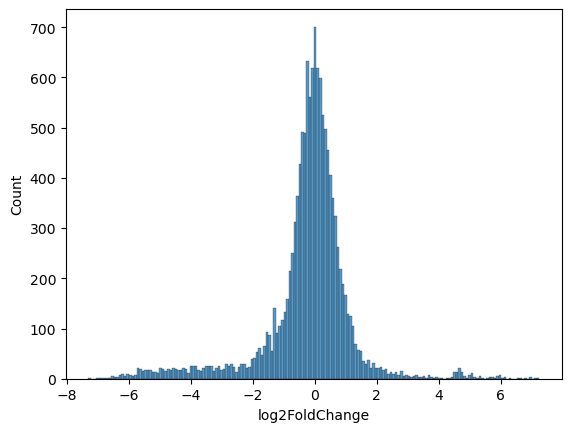

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 


count_file = pd.read_csv('/home/hanna/Desktop/RnD/toxicology/toxicology_modules/QC_modules/BIOS2931_qc_filtered/counts_qc_passed.csv', index_col=0)
annotation_file = pd.read_csv('/home/hanna/Desktop/RnD/toxicology/toxicology_modules/DEG_modules/BIOS2931_deg_annot_numeric.csv', index_col=0)


# test=pd.concat([count_file.filter(regex='MDA_DACTO_1uM') ,count_file.filter(regex='MDA_DMSO') ],axis=1)#.to_csv('MDA_DACTO.csv')
# test_annot = pd.DataFrame(data=test.columns, columns=['Exp'])
# test_annot['Condition']=test_annot['Exp'].str.split('_').str[1]
# test_annot.iloc[3:,1]='control'

# test_annot

# with open('../tempo_salvo/MDA_DACTO_annot.txt','w') as outfile:
#     outfile.write(f"Exp\tCondition\n")
#     for index,row in test_annot.iterrows():
#         outfile.write(row['Exp']+'\t'+row['Condition']+'\n')



deg= pd.read_csv('/home/hanna/Desktop/RnD/toxicology/toxicology_modules/tempo_salvo/here/DACTO_control_deg.txt',sep=',')
deg[deg['padj']<0.05]
sns.histplot(data=deg, x='log2FoldChange')

In [2]:
deg['Gene_Symbol']=deg['Unnamed: 0'].str.split('_').str[0]

In [3]:
deg_p = deg[deg['padj']<0.05]

In [4]:
deg_bad = deg[deg['padj']>=0.05]
deg_bad =deg_bad[~deg_bad['Gene_Symbol'].isin(deg_p['Gene_Symbol'])]
deg_bad['log2FoldChange']=0
deg_bad

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Gene_Symbol
1,AAMP_2,302.674304,0,0.245688,0.324147,0.745827,0.880416,AAMP
2,AARS1_3,169.933839,0,0.351130,-0.407873,0.683367,0.854769,AARS1
3,AATF_4,31.194386,0,0.504936,0.593712,0.552705,0.778666,AATF
5,ABCC2_22,1.835102,0,3.728618,-0.889949,0.373493,0.646231,ABCC2
6,ABCC5_26,328.144148,0,0.439071,2.130048,0.033168,0.148657,ABCC5
...,...,...,...,...,...,...,...,...
22521,ERH_92452,11.813685,0,1.609794,0.400659,0.688671,0.855434,ERH
22522,PFDN4_92453,10.665164,0,1.143670,-1.190841,0.233716,0.499052,PFDN4
22523,NAMPT_92507,8.613671,0,1.564645,-0.657661,0.510756,0.748570,NAMPT
22525,EEF1B2_92592,10.192895,0,1.379099,0.089774,0.928467,0.972216,EEF1B2


In [5]:
deg_concat= pd.concat([deg_p, deg_bad])
deg_concat=deg_concat.reset_index(drop=True)
deg_concat

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Gene_Symbol
0,ABCF1_35,742.939142,-0.534532,0.131621,-4.061150,0.000049,0.001142,ABCF1
1,AGL_162,107.849103,1.017615,0.237584,4.283173,0.000018,0.000509,AGL
2,AIFM1_183,131.399964,-1.138271,0.293323,-3.880603,0.000104,0.002024,AIFM1
3,ALG8_238,21.403782,-1.984803,0.717763,-2.765263,0.005688,0.042398,ALG8
4,AMD1_247,144.779622,-1.302400,0.367581,-3.543164,0.000395,0.005891,AMD1
...,...,...,...,...,...,...,...,...
12631,ERH_92452,11.813685,0.000000,1.609794,0.400659,0.688671,0.855434,ERH
12632,PFDN4_92453,10.665164,0.000000,1.143670,-1.190841,0.233716,0.499052,PFDN4
12633,NAMPT_92507,8.613671,0.000000,1.564645,-0.657661,0.510756,0.748570,NAMPT
12634,EEF1B2_92592,10.192895,0.000000,1.379099,0.089774,0.928467,0.972216,EEF1B2


In [7]:
deg_concat[['Gene_Symbol','log2FoldChange']].to_csv('BIOS2931_DACTO_deg.csv',index=False)

In [ ]:
# deg_concat.to_csv('BIOS2931_DACTO_deg.csv',index=False)